## Exploratory Data Analysis

In [27]:
# 1) Go to repo
%cd /home/jupyter-guotq/HelpHerInvest

# 2) Sync latest from GitHub before editing
!git pull --rebase origin main

/home/jupyter-guotq/HelpHerInvest
From https://github.com/tongyuguo/HelpHerInvest
 * branch            main       -> FETCH_HEAD
Already up to date.


In [28]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings("ignore")

In [29]:
import os

# list available data files

repo_dir = "."
!ls -lah {repo_dir}/Data


total 17M
drwxr-xr-x 2 jupyter-guotq jupyter-guotq  186 Feb  6 01:58 .
drwxr-xr-x 9 jupyter-guotq jupyter-guotq 4.0K Feb  6 02:11 ..
-rw-r--r-- 1 jupyter-guotq jupyter-guotq 2.4M Jan 31 01:15 dependent_variables.csv
-rw-r--r-- 1 jupyter-guotq jupyter-guotq 2.8M Feb  6 01:58 final_dataset.csv
-rw-r--r-- 1 jupyter-guotq jupyter-guotq 1.1M Feb  6 01:58 final_dataset.csv.zip
-rw-r--r-- 1 jupyter-guotq jupyter-guotq 674K Jan 31 01:15 independent_variables.csv
-rw-r--r-- 1 jupyter-guotq jupyter-guotq 9.2M Jan 29 18:07 stock_symbols_new.csv.zip
-rw-r--r-- 1 jupyter-guotq jupyter-guotq 296K Jan 30 21:22 testing_small.csv.zip


In [30]:
import zipfile
# Create Data directory path 
DATA_DIR = Path(repo_dir) / "Data"
# Load the dataset
dataset_path= DATA_DIR / "final_dataset.csv.zip"
print(dataset_path)
csv_file_name = "final_dataset.csv"


with zipfile.ZipFile(dataset_path, 'r') as zf:
    with zf.open(csv_file_name) as file_handle:
        # Read the file-like object directly into pandas
        merged_df = pd.read_csv(file_handle)

Data/final_dataset.csv.zip


In [31]:
# Load the dataset
idx = len(merged_df.index)
print(f"Dataset loaded with {idx} rows.")

train_num = int(idx * 0.7)
val_num = int(idx * 0.15)
test_num = idx - train_num - val_num
print(f"Train set: {train_num} rows"
      f"\nValidation set: {val_num} rows"
      f"\nTest set: {test_num} rows")

training_data = merged_df.iloc[:train_num]
training_data.tail()

Dataset loaded with 9018 rows.
Train set: 6312 rows
Validation set: 1352 rows
Test set: 1354 rows


,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return
6307,2021-06-30,KO,-0.664909,-0.725725,-1.178227,-0.658839,-0.543735,-0.725725,-1.178227,-0.658839,-1.460881,-1.031446,0.215115,0.27088,-0.963440,47.294609,-0.005968,0.111061
6308,2021-06-30,MS,-0.312631,0.928687,1.010281,1.192557,1.301193,0.928687,1.010281,1.192557,0.227042,-0.099618,0.514905,0.55748,1.392062,78.470230,-0.031146,0.085883
6309,2021-06-30,AZN,0.251339,1.117750,0.222708,-0.836243,-0.916816,1.117750,0.222708,-0.836243,1.017971,0.052143,0.514905,0.55748,0.068075,110.269676,-0.154453,-0.037424
6310,2021-06-30,CSCO,-0.412172,-0.747593,0.079779,-0.862740,-0.812849,-0.747593,0.079779,-0.862740,-0.814890,-0.779071,0.514905,0.55748,0.012837,46.186298,0.095101,0.212130
6311,2021-06-30,CAT,-1.992531,-1.725354,0.110645,0.704804,1.364474,-1.725354,0.110645,0.704804,-0.271047,-0.169314,-1.572799,-1.43837,-0.509397,199.377823,-0.156697,-0.039668


In [32]:
# Perform basic EDA
count_nas = training_data.isna().sum()
print("Missing values per column:")
print(count_nas)

# Summary statistics
training_data.describe()


Missing values per column:
Date                  0
Ticker                0
mom_1m                0
mom_3m               96
mom_6m              240
mom_12m             526
mom_12m_ex_1m       526
rel_3m_spy           96
rel_6m_spy          240
rel_12m_spy         526
vol_3m               96
vol_6m              241
drawdown_6m         192
drawdown_12m        479
pct_above_200dma    388
adj_close             0
fwd_excess            0
fwd_return            0
dtype: int64


,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return
count,6312.000000,6216.000000,6072.000000,5786.000000,5786.000000,6216.000000,6072.000000,5786.000000,6216.000000,6071.000000,6120.000000,5833.000000,5924.000000,6312.000000,6312.000000,6312.000000
mean,0.002863,0.003779,0.005591,0.008231,0.007929,0.003779,0.005591,0.008231,0.010924,0.010749,-0.002114,-0.001277,0.005295,63.114141,0.034056,0.110603
std,1.006955,1.007301,1.008082,1.008781,1.008683,1.007301,1.008082,1.008781,1.006466,1.006531,1.005151,1.005172,1.007927,60.450825,0.233581,0.249181
min,-4.941975,-4.616448,-4.855368,-3.909592,-3.897538,-4.616448,-4.855368,-3.909592,-1.746743,-1.669030,-6.121311,-6.307731,-5.148334,0.210643,-0.742708,-0.761706
25%,-0.568056,-0.579037,-0.569720,-0.529152,-0.536417,-0.579037,-0.569720,-0.529152,-0.641027,-0.635937,-0.356688,-0.361195,-0.568757,22.894295,-0.083384,-0.018780
50%,-0.047140,-0.071575,-0.105291,-0.147831,-0.152973,-0.071575,-0.105291,-0.147831,-0.256803,-0.265028,0.397425,0.369031,-0.063726,45.524954,0.011648,0.084548
75%,0.522415,0.506885,0.454105,0.346506,0.364365,0.506885,0.454105,0.346506,0.366834,0.377619,0.630456,0.639367,0.499260,83.734716,0.111277,0.200053
max,6.164418,6.110228,6.533410,6.526852,6.353619,6.110228,6.533410,6.526852,6.000460,5.679121,1.660461,1.562580,5.877712,662.283752,4.020147,4.103457


We retrieved the summary statistics for the "fwd_excess" variable of the 50 tickers generated. Additionally, we drilled down to each ticker to and sorted them by the average "fwd_eccces" variable to see which tickers had the highest values. Many of the tickers are highly traded symbols now (PLTR, TSLA, NVDA, etc.), but one thing that jumps out is how PLTR doesn't have as many observations as the other tickers because it is a recently listed symbol.

In [33]:
# Analyze the target variable 'fwd_excess'
print(training_data['fwd_excess'].describe())

# By ticker - mean
ticker_group = training_data.groupby("Ticker")['fwd_excess'].describe().sort_values('mean', ascending=False)
ticker_group

# By ticker - sum
#ticker_group = training_data.groupby("Ticker")['fwd_excess'].sum().sort_values(ascending=False)
#ticker_group

count    6312.000000
mean        0.034056
std         0.233581
min        -0.742708
25%        -0.083384
50%         0.011648
75%         0.111277
max         4.020147
Name: fwd_excess, dtype: float64


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
TSLA,132.0,0.343586,0.800536,-0.511812,-0.111229,0.086031,0.365226,4.020147
NFLX,137.0,0.203107,0.501023,-0.698185,-0.106404,0.151981,0.385885,2.376051
NVDA,137.0,0.195739,0.367165,-0.436245,-0.029262,0.085357,0.415260,1.423459
AMD,137.0,0.147773,0.502850,-0.742708,-0.204725,0.041220,0.410807,2.323218
AVGO,137.0,0.105272,0.165957,-0.196993,-0.028021,0.086841,0.197614,0.566537
META,109.0,0.101172,0.218840,-0.293504,-0.025067,0.062503,0.184757,1.033359
AMZN,137.0,0.095740,0.205740,-0.321286,-0.041970,0.070517,0.245249,0.640745
ASML,137.0,0.093080,0.146323,-0.213727,0.021243,0.095200,0.168726,0.513613
MU,137.0,0.091248,0.348412,-0.472740,-0.212027,0.052406,0.326857,1.122790


Below is a chart that displays the average "fwd_excess" over the course of the review period. This determines the average across all 50 tickers and provides a good representation of what this portfolio of 50 names could potentially return against the S&P 500 if the weights were evenly distributed. This is something interesting to note.

<Axes: title={'center': 'Mean "fwd_excess" Over Time'}, xlabel='Date', ylabel='Mean fwd_excess'>

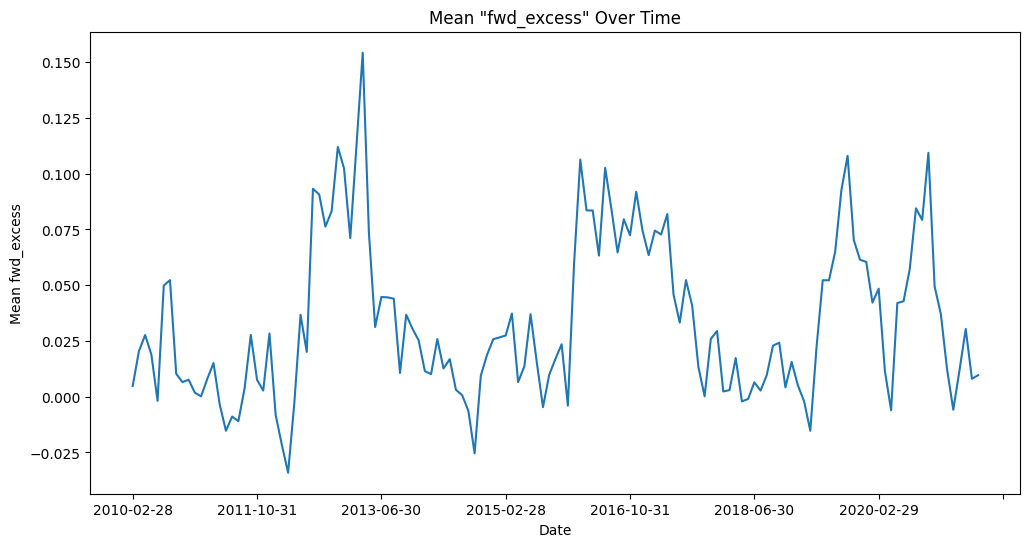

In [34]:
# Average 'fwd_excess' over time
date_group = training_data.groupby('Date')['fwd_excess'].mean()
date_group.plot(title='Mean "fwd_excess" Over Time', figsize=(12,6), ylabel='Mean fwd_excess', xlabel='Date')

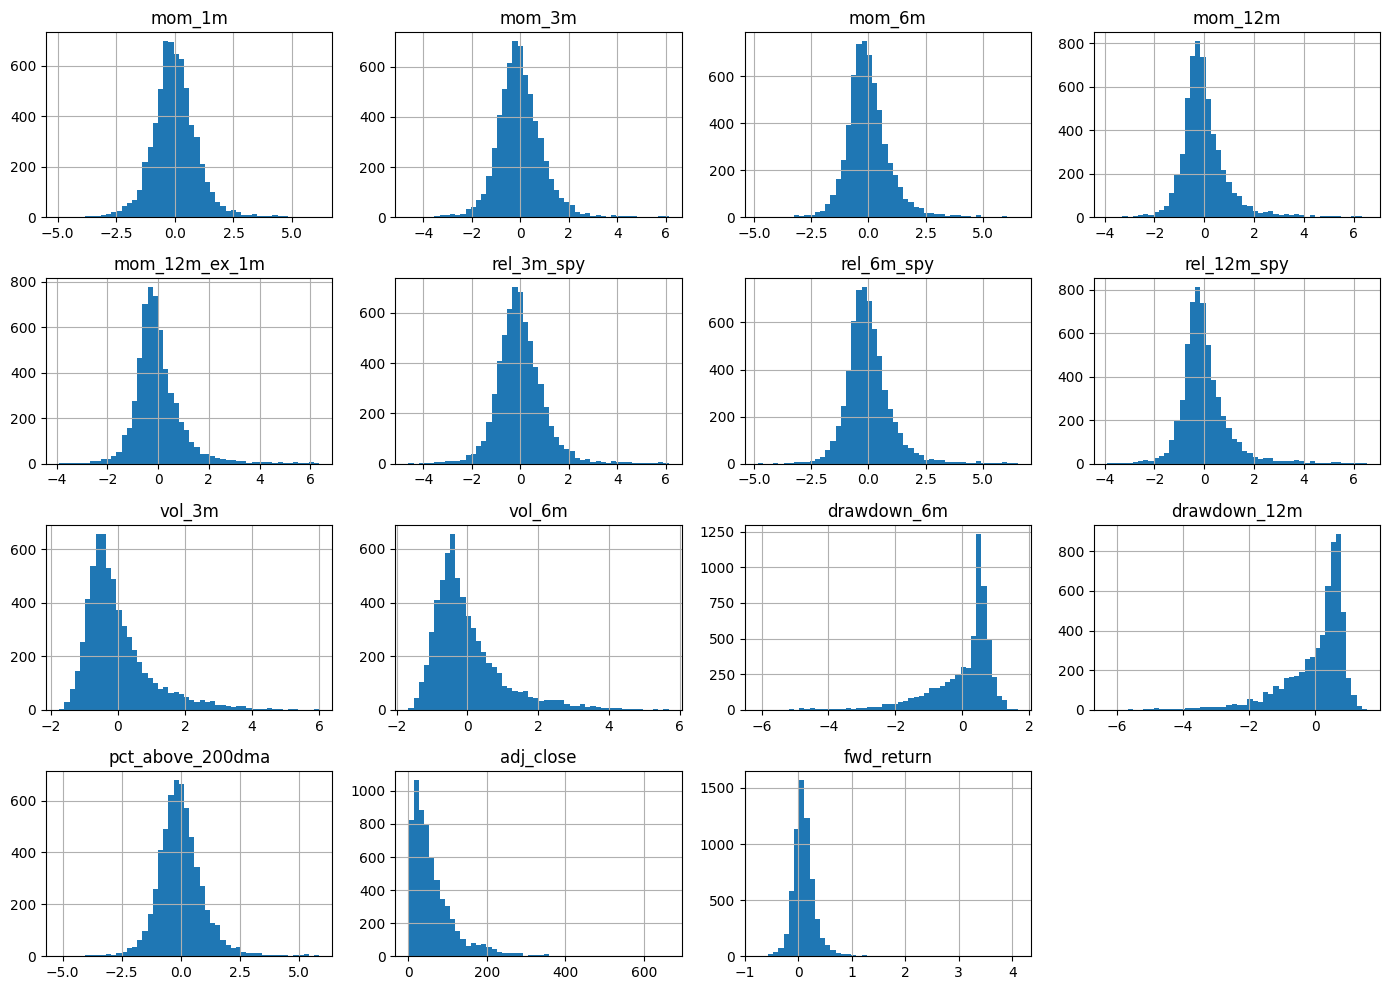

In [35]:
# Histogram of variables

cols = training_data.columns.drop(['fwd_excess','Date'])
training_data[cols].hist(figsize=(14, 10), bins=50)
plt.tight_layout()
plt.show()

The histograms above display the distribution of values for each variable. Many of these are fairly normally distributed, but the volatility variables are slightly right-skewed and the drawdown variables are slightly left-skewed.

Correlation of features with 'fwd_excess':
drawdown_12m       -0.061281
drawdown_6m        -0.036104
mom_1m              0.078982
mom_12m_ex_1m       0.086621
rel_12m_spy         0.105410
mom_12m             0.105410
mom_3m              0.106769
rel_3m_spy          0.106769
pct_above_200dma    0.110647
rel_6m_spy          0.117103
mom_6m              0.117103
vol_3m              0.251590
vol_6m              0.275100
fwd_return          0.948606
fwd_excess          1.000000
dtype: float64


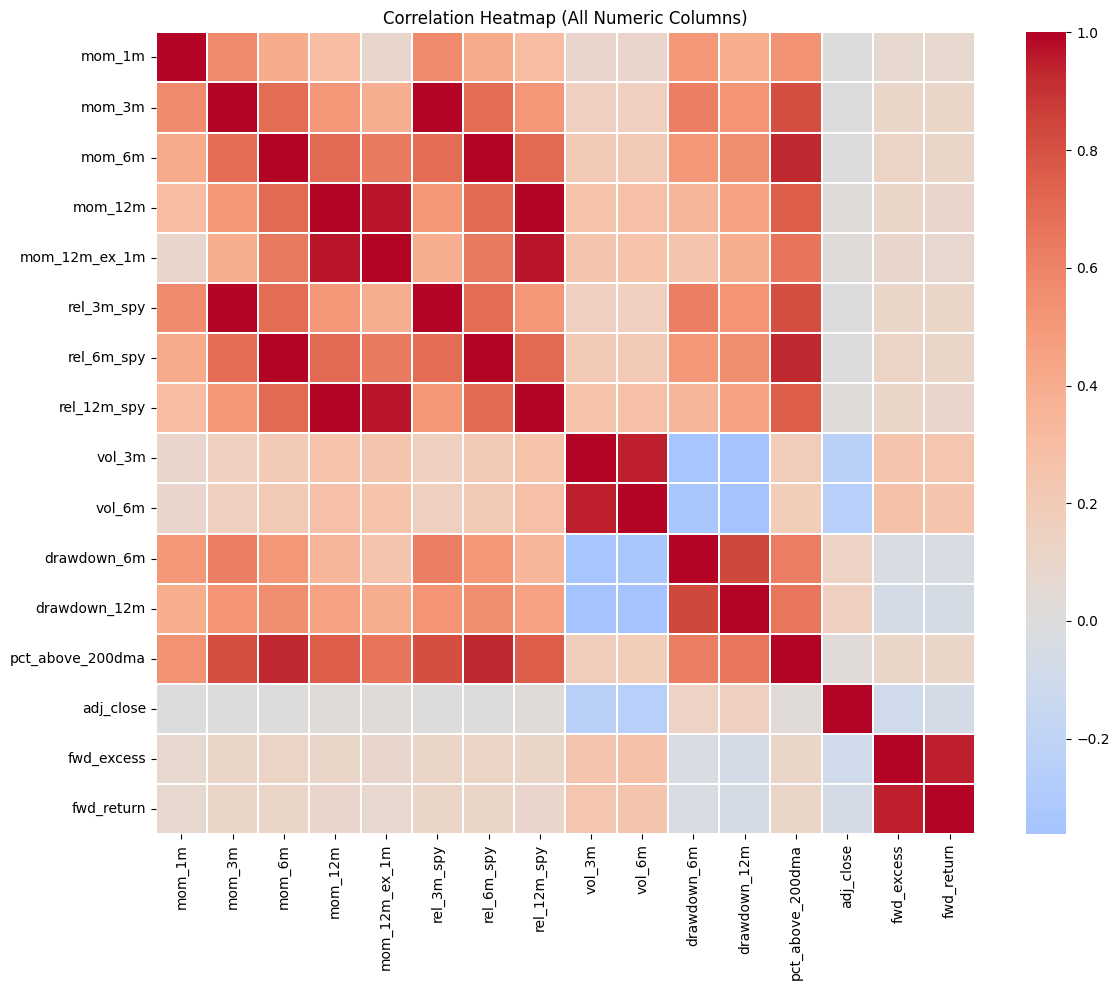

In [36]:
# Correaltion Anlaysis

# select only numeric columns for correlation
numeric_data = training_data.select_dtypes(include=[np.number])
corr = training_data.select_dtypes(include='number').corr()

fwd_excess_corr = numeric_data.corrwith(numeric_data['fwd_excess']).sort_values()
print("Correlation of features with 'fwd_excess':")
print(fwd_excess_corr.tail(15))

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.2)
plt.title('Correlation Heatmap (All Numeric Columns)')
plt.tight_layout()
plt.show()


The correlation analysis does not provide strong positive or negative results for the "fwd_excess" variable. I am curious to see if this is consistent with most tickers and if the timeframe is too wide. Adjusting these parameters may produce stronger correlations. 

<Axes: title={'center': 'Rolling corr: mom_12m vs fwd_excess'}, xlabel='Date', ylabel='Correlation'>

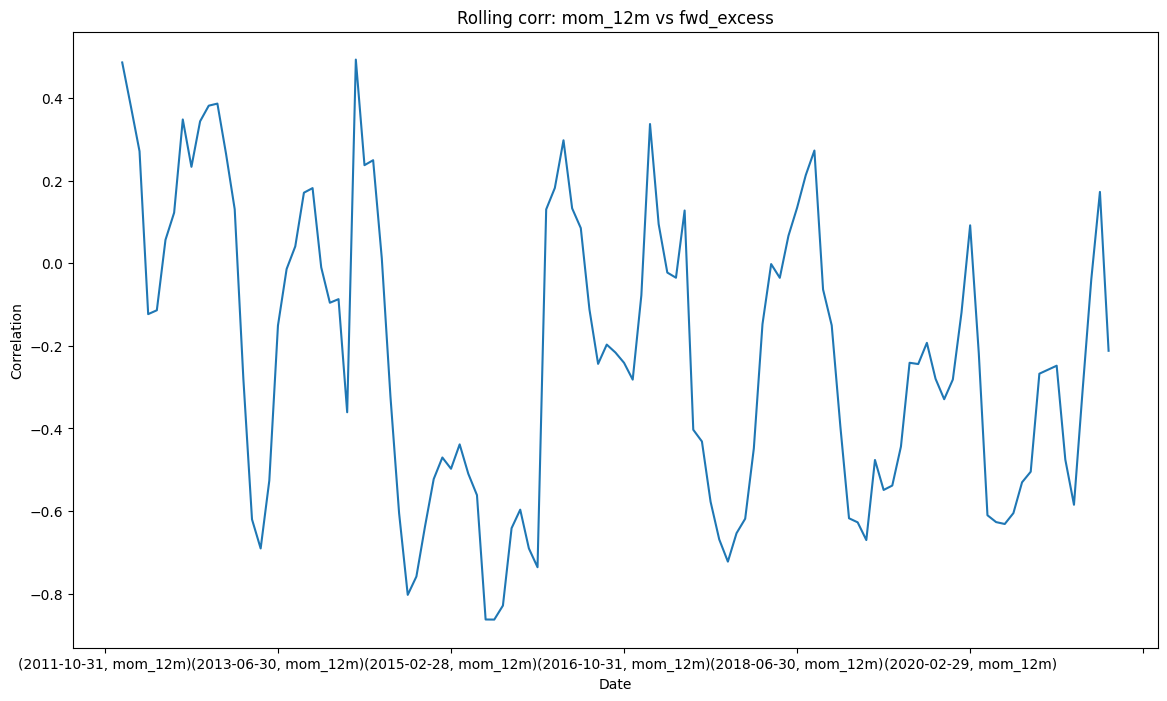

In [37]:
# Example rolling correlation by date
tmp = training_data.reset_index()
tmp = tmp.sort_values('Date')
roll = tmp.groupby('Date')[['mom_12m','fwd_excess']].mean().rolling(12).corr().iloc[0::2,1]
roll.plot(title='Rolling corr: mom_12m vs fwd_excess', figsize=(14,8), ylabel='Correlation', xlabel='Date')


<Axes: title={'center': 'Cross-sectional corr by Date'}, xlabel='Date', ylabel='Correlation'>

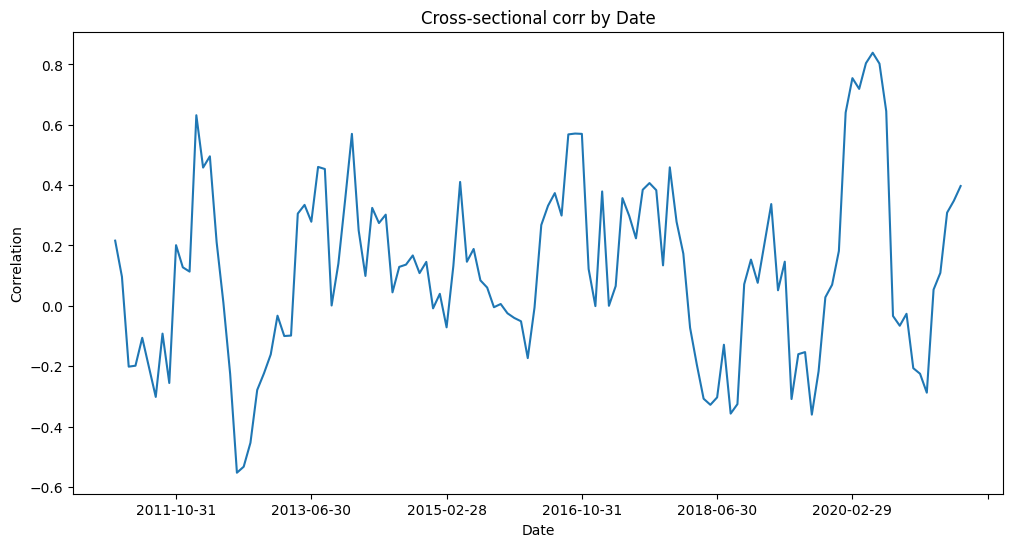

In [38]:
''' 
Cross ‑ sectional analysis per date
For each month, examine signal effectiveness cross‑sectionally
Rank features by how well they explain fwd_excess
'''

# Cross-sectional correlation per date
cs_corr = tmp.groupby('Date').apply(lambda g: g['mom_12m'].corr(g['fwd_excess']))
cs_corr.plot(title='Cross-sectional corr by Date',figsize=(12,6), ylabel='Correlation', xlabel='Date')

In [39]:
'''
Potential Outlier influence
Extreme fwd_excess tails: which tickers/dates drive them?
Winsorization sensitivity checks
'''

q = training_data['fwd_excess'].quantile([0.01, 0.99])
tail = training_data[(training_data['fwd_excess']<=q.iloc[0]) | (training_data['fwd_excess']>=q.iloc[1])]
tail.reset_index().groupby('Ticker').size().sort_values(ascending=False).head(10)

Ticker
AMD     22
TSLA    21
NFLX    20
NVDA    13
GE      11
MU       9
BABA     7
WFC      6
BAC      4
PLTR     3
dtype: int64

In [40]:
# 4) Check what changed
!git status -sb

# 5) Stage + commit
#!git add -A
#!git commit -m "hopefull final testing of working and output directory"

# 6) Push
#!git push

## main...origin/main
